In [40]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
import builtins

# Safely reading and fixing the format of the JSON data using builtins' open
file_path = './Comment_scraper/wfla_comments.json'  # Path to your file

# Read the file using builtins' open
with builtins.open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

# # Load the dataset
# file_path = './kamala_harris.json'
with open(file_path, 'r') as f:
    data = json.load(f)

# Convert JSON to DataFrame
df = pd.json_normalize(data)

# Basic Exploration
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   author                 344 non-null    object
 1   authorProfileImageUrl  344 non-null    object
 2   authorChannelUrl       344 non-null    object
 3   text                   344 non-null    object
 4   likeCount              344 non-null    int64 
 5   publishedAt            344 non-null    object
 6   updatedAt              344 non-null    object
 7   canRate                344 non-null    bool  
 8   viewerRating           344 non-null    object
 9   isPublic               344 non-null    bool  
dtypes: bool(2), int64(1), object(7)
memory usage: 22.3+ KB
None
        likeCount
count  344.000000
mean     8.872093
std     22.633625
min      0.000000
25%      0.000000
50%      1.000000
75%      5.000000
max    181.000000


In [41]:
# Display top 5 rows
print(df.head())

                author                              authorProfileImageUrl  \
0         @Jayne-bt5en  https://yt3.ggpht.com/ytc/AIdro_lOLm-ghLUyNeR6...   
1    @sherrellsabree50  https://yt3.ggpht.com/ytc/AIdro_lfKq8uQyk8ytgg...   
2          @CareyBeryl  https://yt3.ggpht.com/ytc/AIdro_l8L0TJqZB5vy_w...   
3  @albertocabrera6614  https://yt3.ggpht.com/ytc/AIdro_ktM1gnOjAyUmeW...   
4        @DannyTubiolo  https://yt3.ggpht.com/Ai_740Ns59RuDfIdJQoaFm9E...   

                             authorChannelUrl  \
0         http://www.youtube.com/@Jayne-bt5en   
1    http://www.youtube.com/@sherrellsabree50   
2          http://www.youtube.com/@CareyBeryl   
3  http://www.youtube.com/@albertocabrera6614   
4        http://www.youtube.com/@DannyTubiolo   

                                                text  likeCount  \
0  Vance won yet showed compassion  by not going ...          0   
1            Shes clearly a Kamalie Harris supporter          0   
2                                 4557 Ka

In [42]:
# Basic statistics
print(f"Total comments: {len(df)}")
print(f"Unique authors: {df['author'].nunique()}")

Total comments: 344
Unique authors: 311


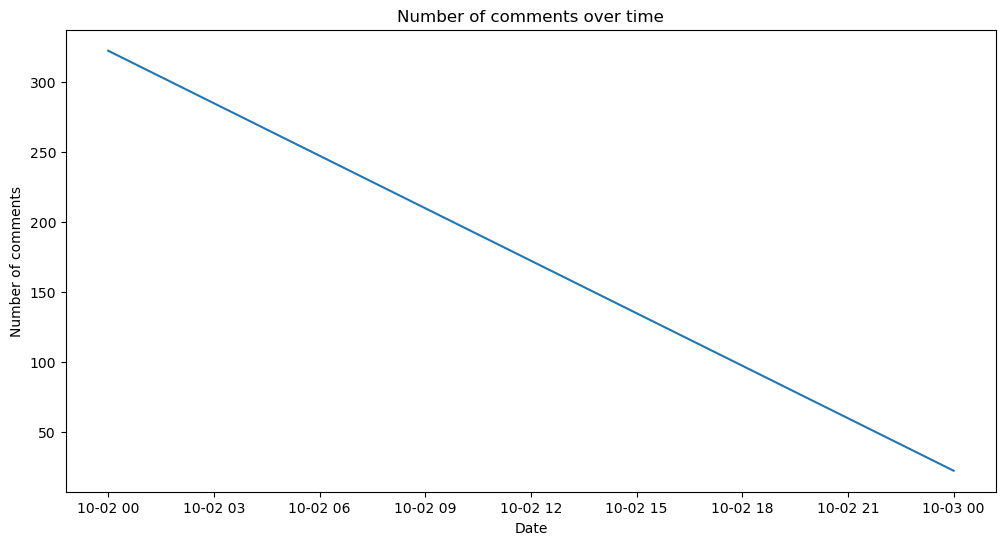

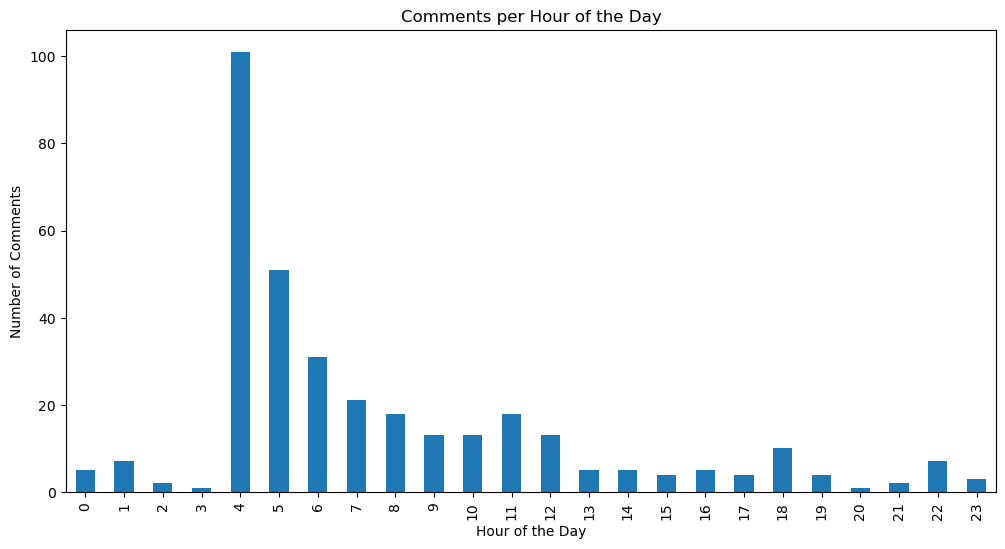

In [43]:
import matplotlib.pyplot as plt

# Convert 'publishedAt' to datetime
df['publishedAt'] = pd.to_datetime(df['publishedAt'])

# Add a column for the date and hour to analyze trends
df['date'] = df['publishedAt'].dt.date
df['hour'] = df['publishedAt'].dt.hour

# Plotting the number of comments over time
plt.figure(figsize=(12,6))
df['date'].value_counts().sort_index().plot(kind='line', title="Number of comments over time")
plt.xlabel('Date')
plt.ylabel('Number of comments')
plt.show()

# Comments per hour of the day
plt.figure(figsize=(12,6))
df.groupby('hour')['text'].count().plot(kind='bar', title="Comments per Hour of the Day")
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Comments')
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


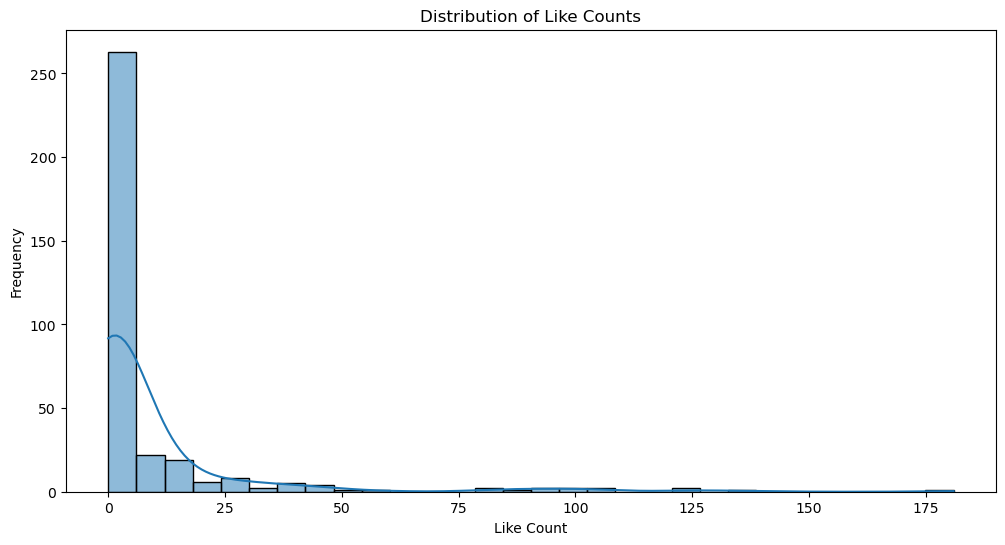

Top 10 Most Liked Comments:
                author                                               text  \
194    @HugoStiglitz88  Anyone thinking Tim Walz won probably still th...   
319    @nezdesigns6839                                    JD Vance won!!!   
305            @jdlcdn            Vance was detailed and did his homework   
329  @DetodoUnpoquin48  100% Vance.\nCalm, clear, confident, convincin...   
128    @Wanderer-uc1sj  Vance did a stellar work and could easily run ...   
234   @LowSteaksGaming                               Vance destroyed Walz   
339         @joannektc  I love that JD Vance was rocking the pink tie ...   
182   @SuperMarlene333  JD was intelligent, well informed,calm collect...   
219        @srharris88  Even with the Biased moderators at CBS, Vance ...   
199       @benniew3097        When an educated person meets a corrupt one   

     likeCount  
194        181  
319        138  
305        126  
329        125  
128        107  
234        103  
339  

In [44]:
import seaborn as sns

# Analyze the like count distribution
plt.figure(figsize=(12,6))
sns.histplot(df['likeCount'], bins=30, kde=True)
plt.title('Distribution of Like Counts')
plt.xlabel('Like Count')
plt.ylabel('Frequency')
plt.show()

# Most liked comments
most_liked = df.sort_values(by='likeCount', ascending=False).head(10)
print("Top 10 Most Liked Comments:")
print(most_liked[['author', 'text', 'likeCount']])

# Top Commenters
top_commenters = df['author'].value_counts().head(10)
print("Top 10 Commenters:")
print(top_commenters)


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


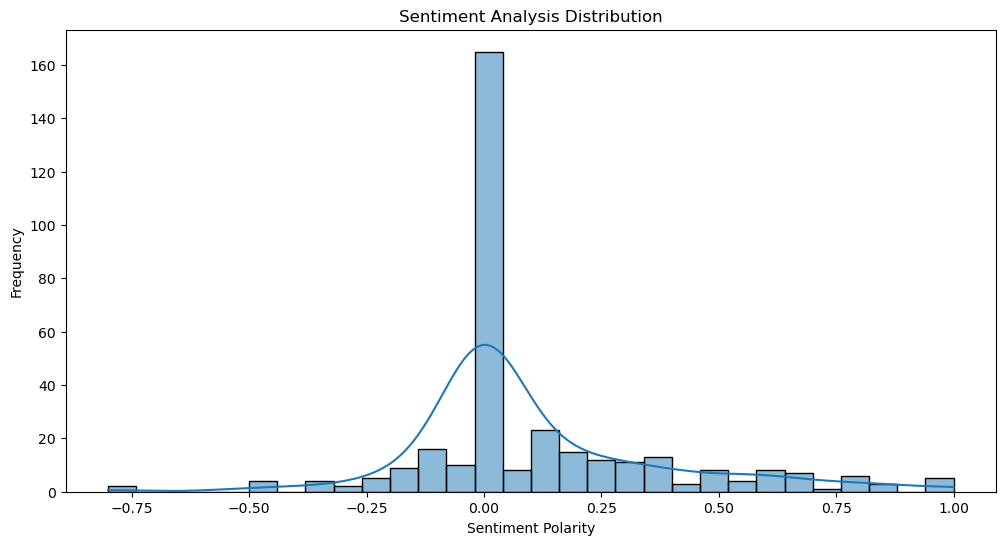

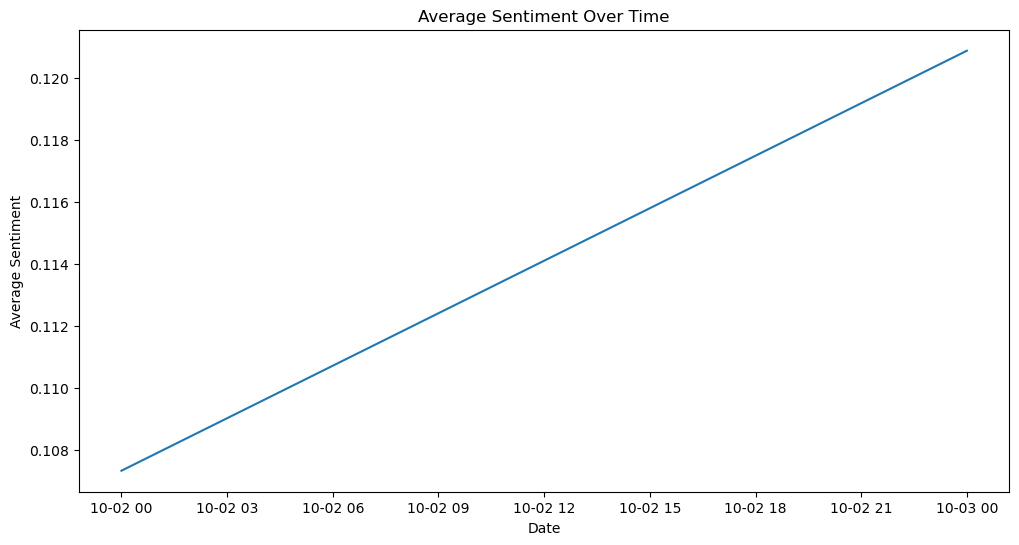

In [45]:
from textblob import TextBlob

# Sentiment Analysis
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

df['sentiment'] = df['text'].apply(get_sentiment)

# Sentiment distribution
plt.figure(figsize=(12,6))
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title('Sentiment Analysis Distribution')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()

# Average sentiment over time
plt.figure(figsize=(12,6))
df.groupby('date')['sentiment'].mean().plot(kind='line', title="Average Sentiment Over Time")
plt.xlabel('Date')
plt.ylabel('Average Sentiment')
plt.show()


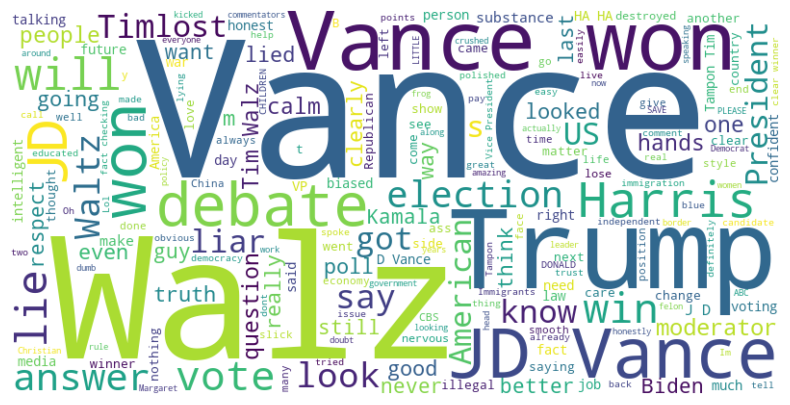

In [46]:
from wordcloud import WordCloud

# WordCloud for most common words in the comments
text = ' '.join(df['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


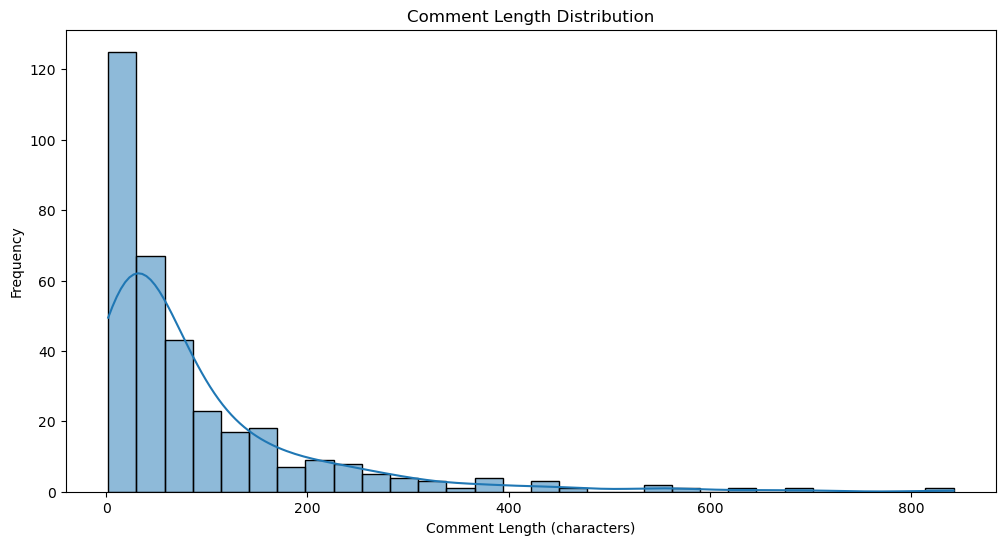

Top 10 Longest Comments:
                   author                                               text  \
257    @rickartdefoix1298  Quite a technical debate as I expected it. Dif...   
191     @ericacameron1454  You can't call yourself a patriot and you supp...   
14    @Annetteshuford1014  Vance completely "gets" the millennial generat...   
179             @JoeZyzyx  I didn't watch or consider the debate as a "wi...   
180       @texjohnson9208  Vance was a slick talker, but slick talking me...   
181      @michaelbrown459  From Russia with Propaganda below. Destroy the...   
139     @DimaGerasimov804  Tim waltz got destroyed. He admired he likes t...   
112         @Jeremy-do2nz  JD Vance won this debate he connected with mid...   
84       @ronnienaron8389  Tim walz is a phony and a liar. I’ve seen vide...   
130  @cornelisdebilde6850  In this election, there is only one crucial de...   

     comment_length  
257             842  
191             694  
14              633  
179   

In [47]:
# Add a column for comment length
df['comment_length'] = df['text'].apply(len)

# Plotting comment length distribution
plt.figure(figsize=(12,6))
sns.histplot(df['comment_length'], bins=30, kde=True)
plt.title('Comment Length Distribution')
plt.xlabel('Comment Length (characters)')
plt.ylabel('Frequency')
plt.show()

# Analyzing the top 10 longest comments
longest_comments = df.sort_values(by='comment_length', ascending=False).head(10)
print("Top 10 Longest Comments:")
print(longest_comments[['author', 'text', 'comment_length']])


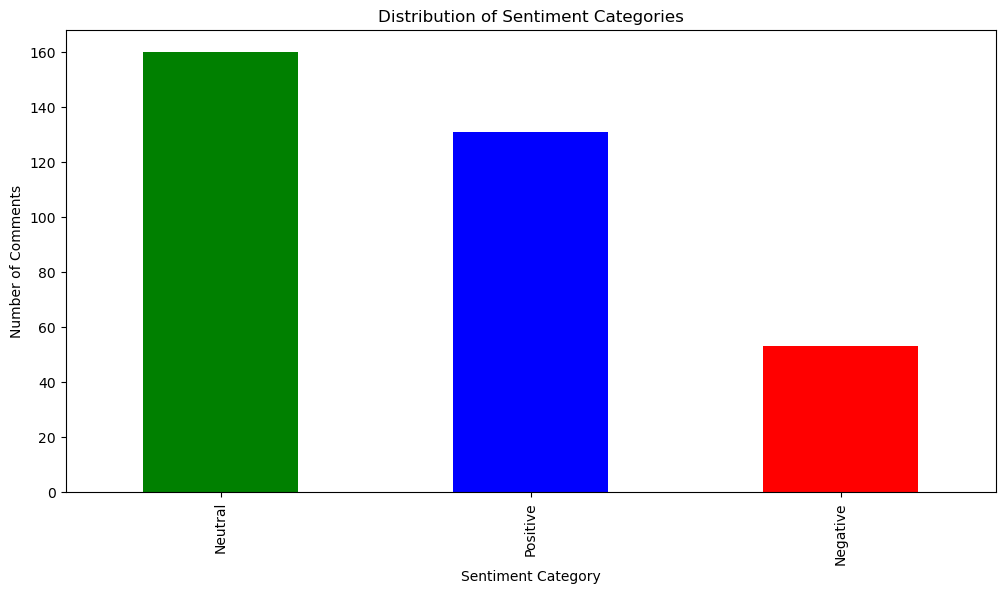

Sentiment Category Percentages:
sentiment_category
Neutral     46.511628
Positive    38.081395
Negative    15.406977
Name: proportion, dtype: float64


In [48]:
# Function to categorize sentiment
def categorize_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

# Apply sentiment categorization
df['sentiment_category'] = df['sentiment'].apply(categorize_sentiment)

# Plotting the distribution of sentiment categories
plt.figure(figsize=(12,6))
df['sentiment_category'].value_counts().plot(kind='bar', color=['green', 'blue', 'red'], title="Distribution of Sentiment Categories")
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Comments')
plt.show()

# Percentage breakdown of sentiment categories
sentiment_percentages = df['sentiment_category'].value_counts(normalize=True) * 100
print("Sentiment Category Percentages:")
print(sentiment_percentages)


In [49]:
# Find duplicate comments
duplicate_comments = df[df.duplicated(subset=['text'], keep=False)]

# Show duplicate comments
print("Potential Spam-like Comments:")
print(duplicate_comments[['author', 'text']])

# Count the number of duplicates
num_duplicates = duplicate_comments.shape[0]
print(f"Number of Potential Spam-like Comments: {num_duplicates}")


Potential Spam-like Comments:
                    author                                               text
12            @Libbertyone  Look if you are a Christian nationalist, vote ...
13            @Libbertyone  Look if you are a Christian nationalist, vote ...
82       @deborahmason3290                                              Vance
106    @virginiagascon6089                                              Vance
111       @Introvert_Honey                                         Vance won!
113       @jacsonbayyo3482                                          Vance won
123     @mikeharrelson5268                                          Vance won
137     @matthewwarner5050                                          Vance won
146              @MS-vd9cs                                              Vance
151      @ChrisGoodman-m4r                                              Vance
158      @rodgerdodger3483                                              Vance
165        @SparkedRentals        